<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Multi_Model_Ensemble_Framework_for_Precise_Multi_Class_Epileptic_Seizure_Subtype_Classification_using_High_Resolution_EEG_Signals_A_Comparative_Study_on_the_Bangalore_EEG_Epilepsy_Dataset_(BEED).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
pip install catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.8 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


print("✅ All libraries imported successfully!")
print("CatBoost version:", CatBoostClassifier.__module__)


✅ All libraries imported successfully!
CatBoost version: catboost.core


In [19]:
# ====================== LOAD DATA ======================
df = pd.read_csv("/content/drive/MyDrive/Dataset/BEED_Data.csv")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [20]:
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['y'].value_counts())


Dataset Shape: (8000, 17)

Class Distribution:
 y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [21]:
# Basic statistics
print("\nBasic Statistics:")
print(df.describe().T)

# Check for missing values
print("\nMissing Values:", df.isnull().sum().sum())



Basic Statistics:
      count      mean        std    min    25%  50%    75%    max
X1   8000.0 -1.490375  36.824213 -281.0  -7.00  0.0   8.00  252.0
X2   8000.0 -2.189375  36.108088 -255.0  -7.00  0.0   8.00  261.0
X3   8000.0 -3.237500  35.802490 -255.0  -7.00 -1.0   5.00  238.0
X4   8000.0 -4.119375  36.285268 -257.0 -10.00 -1.0   7.00  246.0
X5   8000.0 -1.821625  37.621284 -264.0 -10.00  0.0  10.00  249.0
X6   8000.0 -2.311750  36.306006 -277.0  -8.00  0.0   8.00  245.0
X7   8000.0 -3.398125  36.358395 -277.0  -8.00 -1.0   6.00  220.0
X8   8000.0 -3.448625  36.522214 -260.0  -7.00 -1.0   5.00  271.0
X9   8000.0 -1.647875  38.107721 -290.0  -7.00  0.0   8.00  280.0
X10  8000.0 -2.561250  37.540680 -302.0  -8.00  0.0   8.00  251.0
X11  8000.0 -3.524500  37.343938 -276.0  -8.00 -1.0   5.00  262.0
X12  8000.0 -4.782750  37.469582 -306.0 -11.00 -2.0   7.00  283.0
X13  8000.0 -2.164000  38.144075 -288.0 -10.00  0.0  10.00  296.0
X14  8000.0 -2.910875  36.640555 -290.0  -8.00  0.0   9.0

In [9]:
# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 75% Train, 10% Validation, 15% Test (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.6, random_state=42, stratify=y_temp
)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Train set: (6000, 16)
Validation set: (800, 16)
Test set: (1200, 16)


In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\n{'='*60}")
    print(f"{model_name} Results")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return model, acc, f1


Logistic Regression Results
Accuracy : 0.4792
Macro F1 : 0.4830

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.55      0.64       300
           1       0.51      0.64      0.57       300
           2       0.39      0.37      0.38       300
           3       0.33      0.36      0.35       300

    accuracy                           0.48      1200
   macro avg       0.50      0.48      0.48      1200
weighted avg       0.50      0.48      0.48      1200



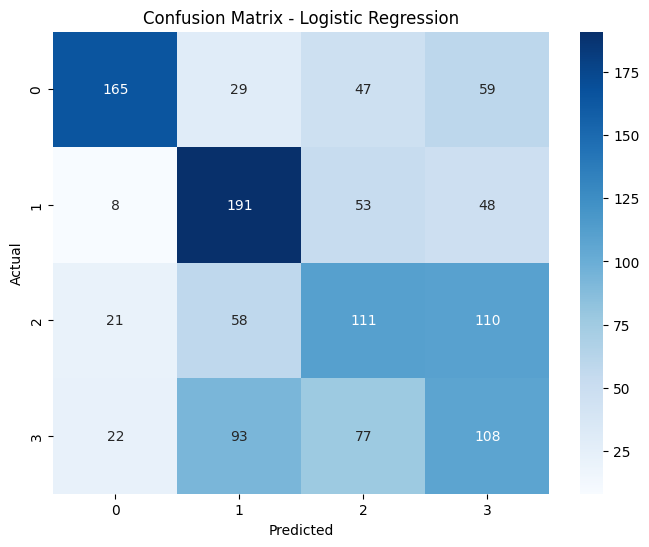


KNN Results
Accuracy : 0.9583
Macro F1 : 0.9585

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       300
           1       0.98      0.93      0.96       300
           2       0.94      0.96      0.95       300
           3       0.91      0.98      0.95       300

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



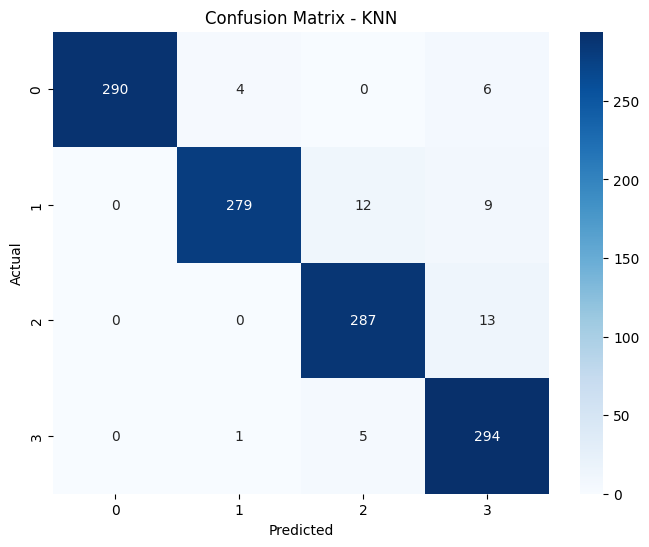


SVM Results
Accuracy : 0.7492
Macro F1 : 0.7323

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       300
           1       0.81      0.75      0.78       300
           2       0.57      0.95      0.71       300
           3       0.75      0.32      0.45       300

    accuracy                           0.75      1200
   macro avg       0.78      0.75      0.73      1200
weighted avg       0.78      0.75      0.73      1200



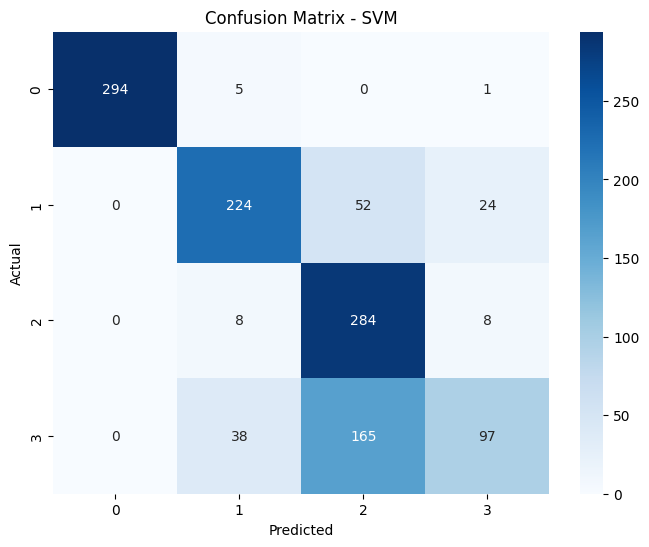


Random Forest Results
Accuracy : 0.9675
Macro F1 : 0.9676

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       300
           1       0.98      0.97      0.97       300
           2       0.94      0.96      0.95       300
           3       0.95      0.95      0.95       300

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



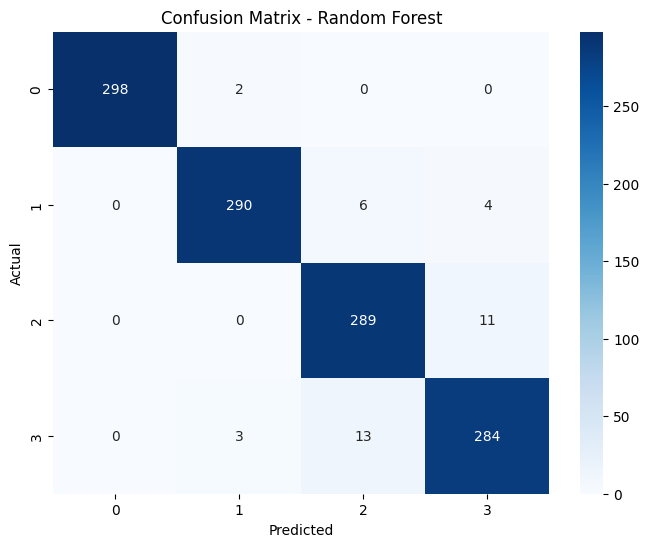


XGBoost Results
Accuracy : 0.9583
Macro F1 : 0.9584

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       300
           1       0.98      0.96      0.97       300
           2       0.93      0.95      0.94       300
           3       0.93      0.92      0.93       300

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



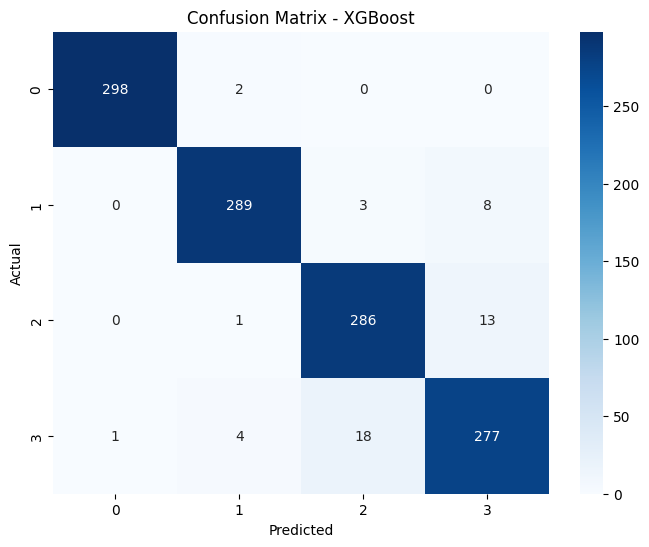


LightGBM Results
Accuracy : 0.9767
Macro F1 : 0.9767

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       0.99      0.96      0.98       300
           2       0.97      0.98      0.97       300
           3       0.95      0.97      0.96       300

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



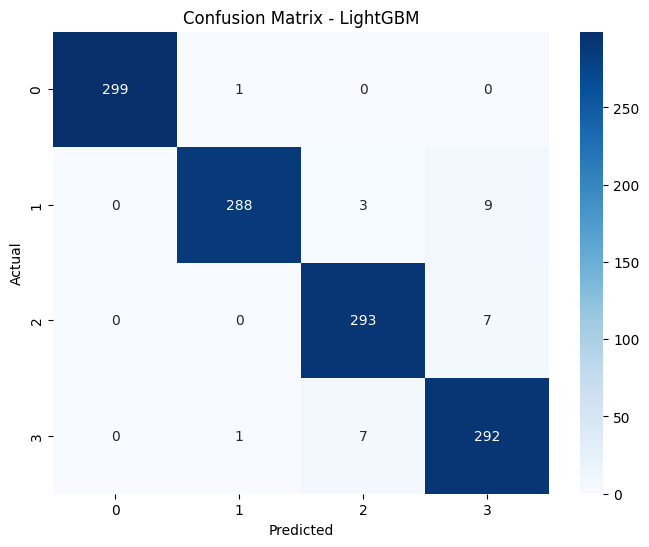


CatBoost Results
Accuracy : 0.9425
Macro F1 : 0.9425

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       0.96      0.95      0.95       300
           2       0.91      0.94      0.92       300
           3       0.91      0.88      0.90       300

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200



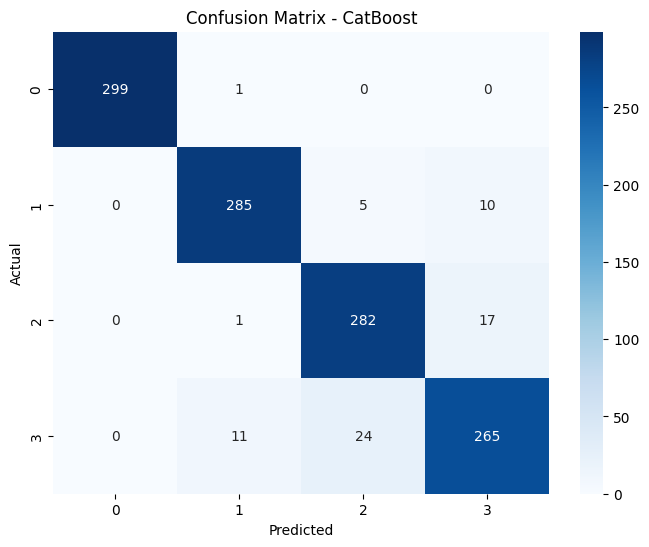

In [11]:
models = {}
results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
models['Logistic Regression'], acc, f1 = evaluate_model(lr, X_train, y_train, X_test, y_test, "Logistic Regression")
results['Logistic Regression'] = (acc, f1)

# 2. KNN
knn = KNeighborsClassifier(n_neighbors=5)
models['KNN'], acc, f1 = evaluate_model(knn, X_train, y_train, X_test, y_test, "KNN")
results['KNN'] = (acc, f1)

# 3. SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
models['SVM'], acc, f1 = evaluate_model(svm, X_train, y_train, X_test, y_test, "SVM")
results['SVM'] = (acc, f1)

# 4. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
models['Random Forest'], acc, f1 = evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest")
results['Random Forest'] = (acc, f1)

# 5. XGBoost
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42, eval_metric='mlogloss', n_jobs=-1)
models['XGBoost'], acc, f1 = evaluate_model(xgb, X_train, y_train, X_test, y_test, "XGBoost")
results['XGBoost'] = (acc, f1)

# 6. LightGBM
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42, verbose=-1)
models['LightGBM'], acc, f1 = evaluate_model(lgbm, X_train, y_train, X_test, y_test, "LightGBM")
results['LightGBM'] = (acc, f1)

# 7. CatBoost
cat = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, verbose=False, random_state=42)
models['CatBoost'], acc, f1 = evaluate_model(cat, X_train, y_train, X_test, y_test, "CatBoost")
results['CatBoost'] = (acc, f1)


MODEL COMPARISON (Sorted by Macro F1)
                     Accuracy  Macro_F1
LightGBM             0.976667  0.976734
Random Forest        0.967500  0.967588
KNN                  0.958333  0.958550
XGBoost              0.958333  0.958388
CatBoost             0.942500  0.942464
SVM                  0.749167  0.732326
Logistic Regression  0.479167  0.482996


<Figure size 1200x600 with 0 Axes>

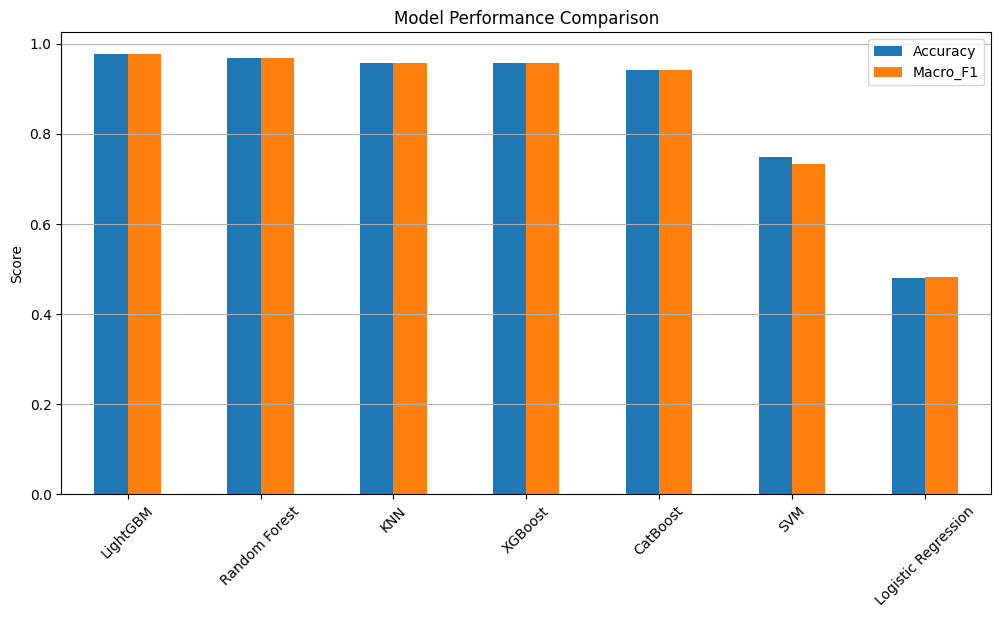

In [12]:
# Results Comparison
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy', 'Macro_F1'])
results_df = results_df.sort_values(by='Macro_F1', ascending=False)
print("\n" + "="*50)
print("MODEL COMPARISON (Sorted by Macro F1)")
print("="*50)
print(results_df)

# Plot Comparison
plt.figure(figsize=(12,6))
results_df.plot(kind='bar', figsize=(12,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


Top 15 Most Important Features (LightGBM):
   Feature  Importance
4       X5        1668
7       X8        1655
15     X16        1629
6       X7        1620
5       X6        1563
3       X4        1521
2       X3        1450
11     X12        1424
10     X11        1418
8       X9        1385
0       X1        1347
14     X15        1319
12     X13        1273
9      X10        1238
1       X2        1235


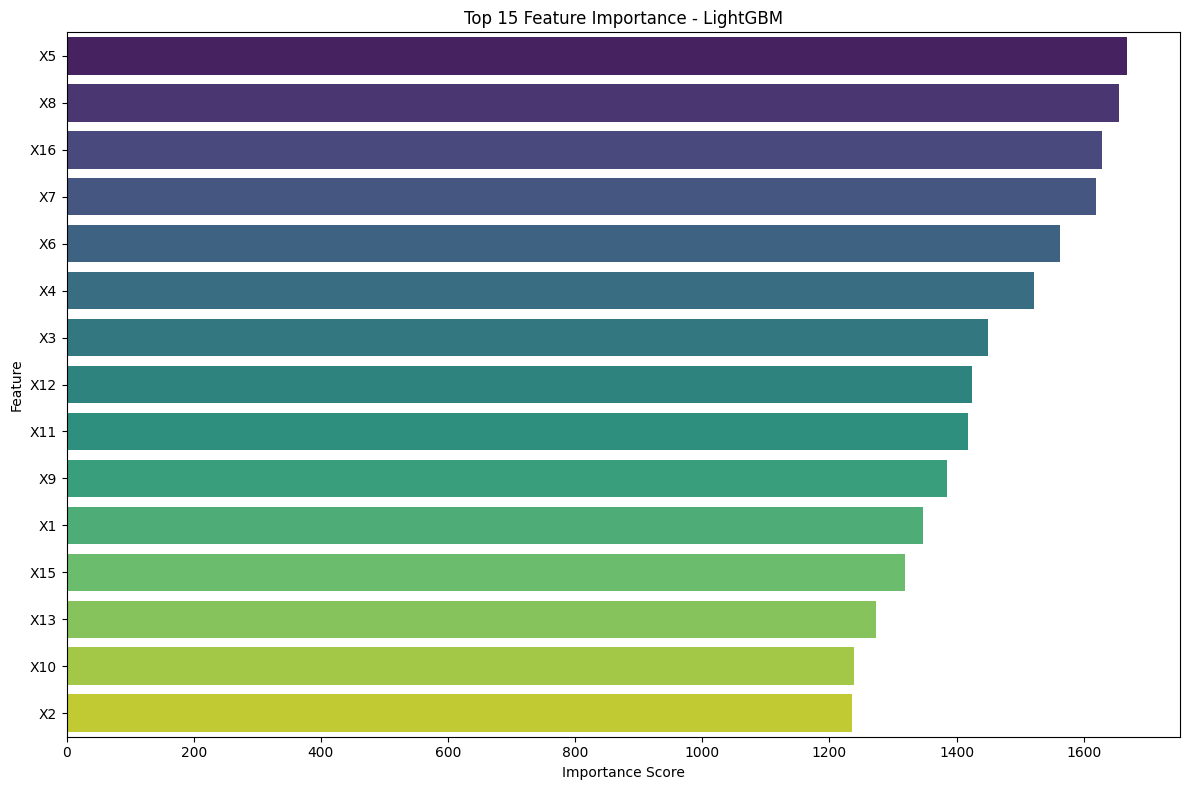

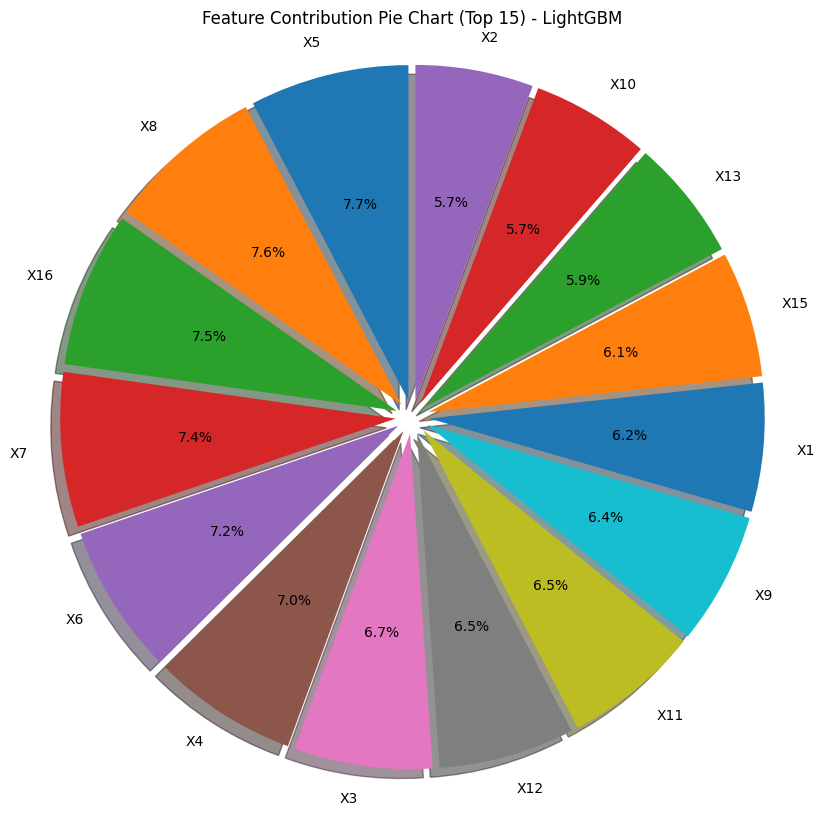

In [13]:
# LightGBM Feature Importance (Top 15)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': models['LightGBM'].feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (LightGBM):")
print(feature_importance.head(15))

# Bar Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importance - LightGBM')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Pie Chart (Top 10 Features Contribution)
top15 = feature_importance.head(15)
plt.figure(figsize=(10, 10))
plt.pie(top15['Importance'], labels=top15['Feature'], autopct='%1.1f%%', startangle=90,
        explode=[0.05]*len(top15), shadow=True)
plt.title('Feature Contribution Pie Chart (Top 15) - LightGBM')
plt.axis('equal')
plt.show()


Training Soft Voting Ensemble...

Soft Voting Ensemble Results
Accuracy : 0.9742
Macro F1 : 0.9743

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       0.99      0.96      0.98       300
           2       0.96      0.97      0.97       300
           3       0.94      0.97      0.96       300

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



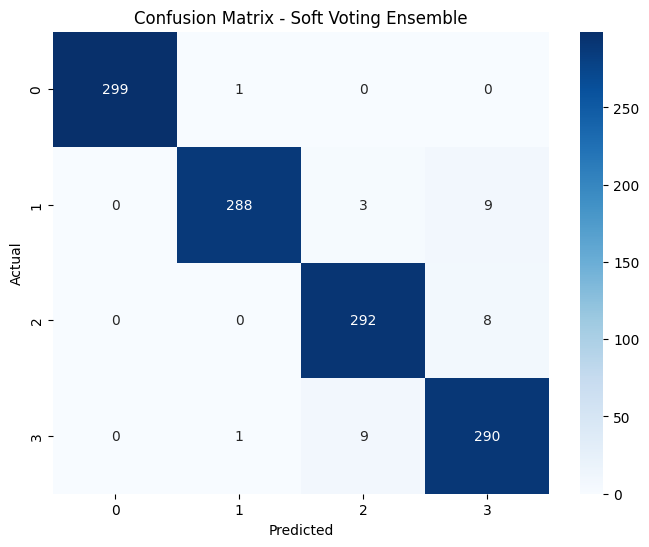

In [14]:
# Soft Voting Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('LightGBM', models['LightGBM']),
        ('Random Forest', models['Random Forest']),
        ('XGBoost', models['XGBoost'])
    ],
    voting='soft',
    weights=[3, 2, 1]
)

print("\nTraining Soft Voting Ensemble...")
ensemble_model, acc, f1 = evaluate_model(ensemble, X_train, y_train, X_test, y_test, "Soft Voting Ensemble")


FINAL MODEL PERFORMANCE TABLE
                  Model  Accuracy  Macro_F1
0              LightGBM    0.9767    0.9767
1  Soft Voting Ensemble    0.9742    0.9743
2         Random Forest    0.9675    0.9676
3                   KNN    0.9583    0.9585
4               XGBoost    0.9583    0.9584
5              CatBoost    0.9425    0.9425
6                   SVM    0.7492    0.7323
7   Logistic Regression    0.4792    0.4830


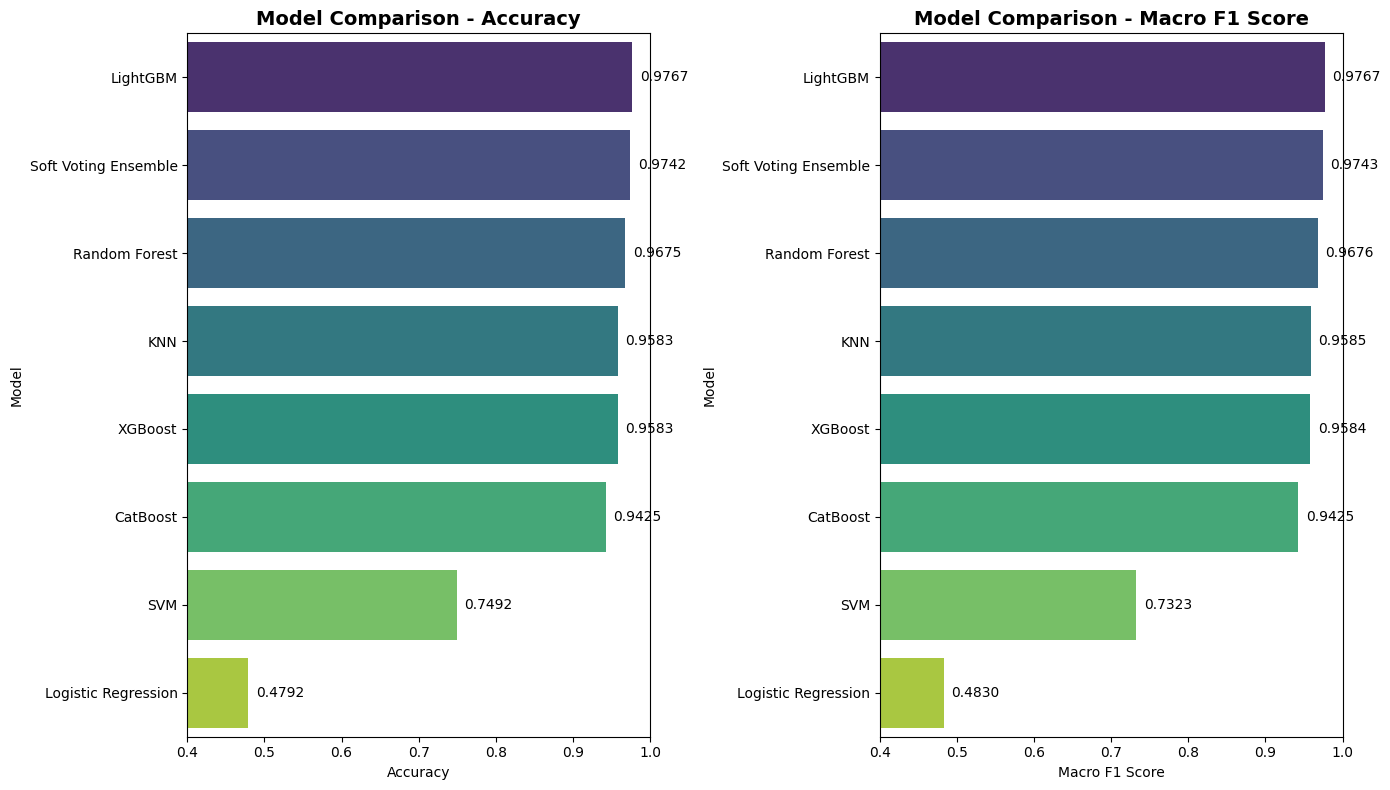

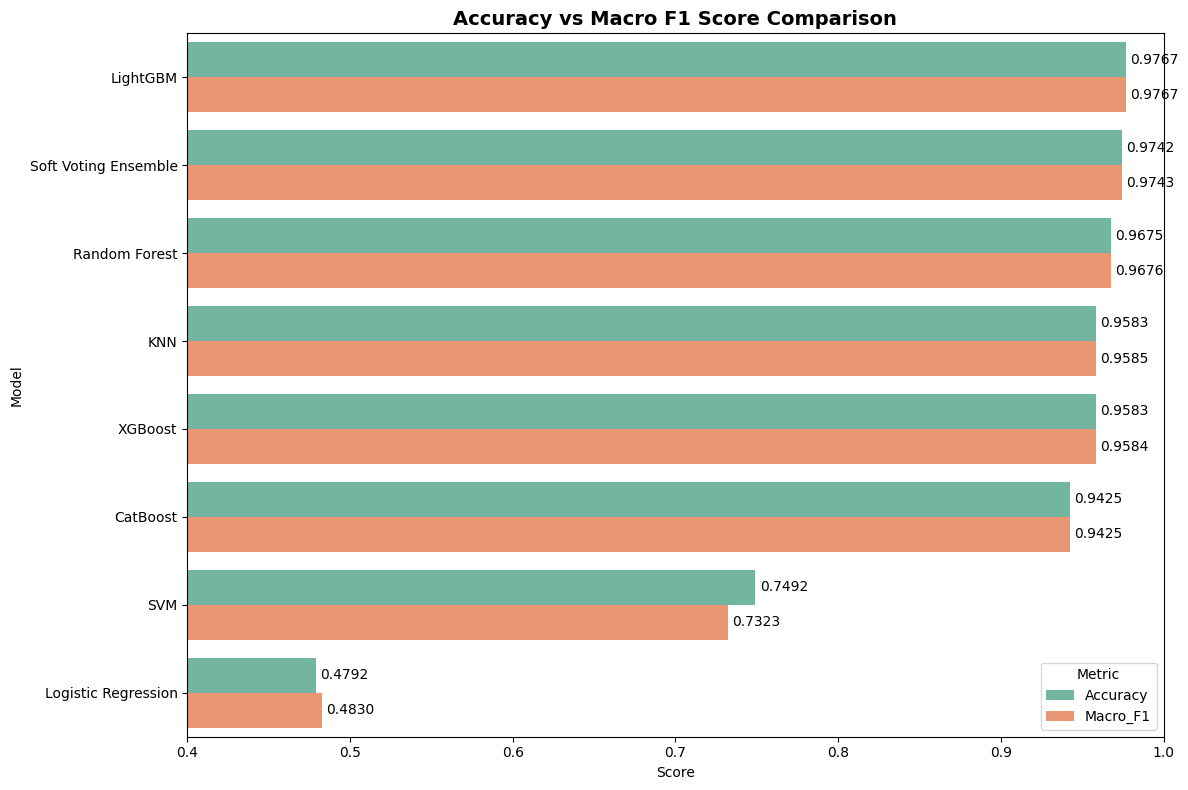

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ====================== FINAL RESULTS TABLE ======================
data = {
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Random Forest',
              'XGBoost', 'LightGBM', 'CatBoost', 'Soft Voting Ensemble'],
    'Accuracy': [0.4792, 0.9583, 0.7492, 0.9675, 0.9583, 0.9767, 0.9425, 0.9742],
    'Macro_F1': [0.4830, 0.9585, 0.7323, 0.9676, 0.9584, 0.9767, 0.9425, 0.9743]
}

results_df = pd.DataFrame(data)
results_df = results_df.sort_values(by='Macro_F1', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FINAL MODEL PERFORMANCE TABLE")
print("="*80)
print(results_df.round(4))

# Save table to CSV (optional)
results_df.to_csv('beed_model_comparison.csv', index=False)

# ====================== BAR CHARTS COMPARISON ======================

plt.figure(figsize=(14, 8))

# Accuracy Bar Plot
plt.subplot(1, 2, 1)
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison - Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy')
plt.xlim(0.4, 1.0)
for i, v in enumerate(results_df['Accuracy']):
    plt.text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=10)

# Macro F1 Bar Plot
plt.subplot(1, 2, 2)
sns.barplot(x='Macro_F1', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison - Macro F1 Score', fontsize=14, fontweight='bold')
plt.xlabel('Macro F1 Score')
plt.xlim(0.4, 1.0)
for i, v in enumerate(results_df['Macro_F1']):
    plt.text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

# ====================== COMBINED BAR PLOT ======================
plt.figure(figsize=(12, 8))
results_melted = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Macro_F1'],
                                 var_name='Metric', value_name='Score')

sns.barplot(x='Score', y='Model', hue='Metric', data=results_melted, palette='Set2')
plt.title('Accuracy vs Macro F1 Score Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Score')
plt.legend(title='Metric')
plt.xlim(0.4, 1.0)

# Add value labels
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

Computing SHAP values for LightGBM (Multi-class)...
Generating SHAP Summary Plots...


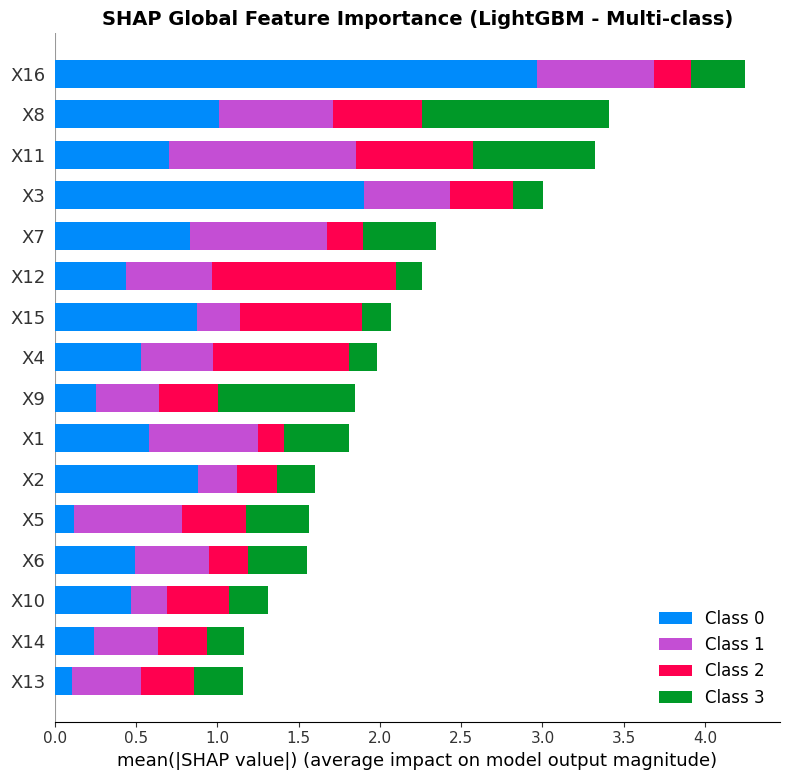

<Figure size 1200x1000 with 0 Axes>

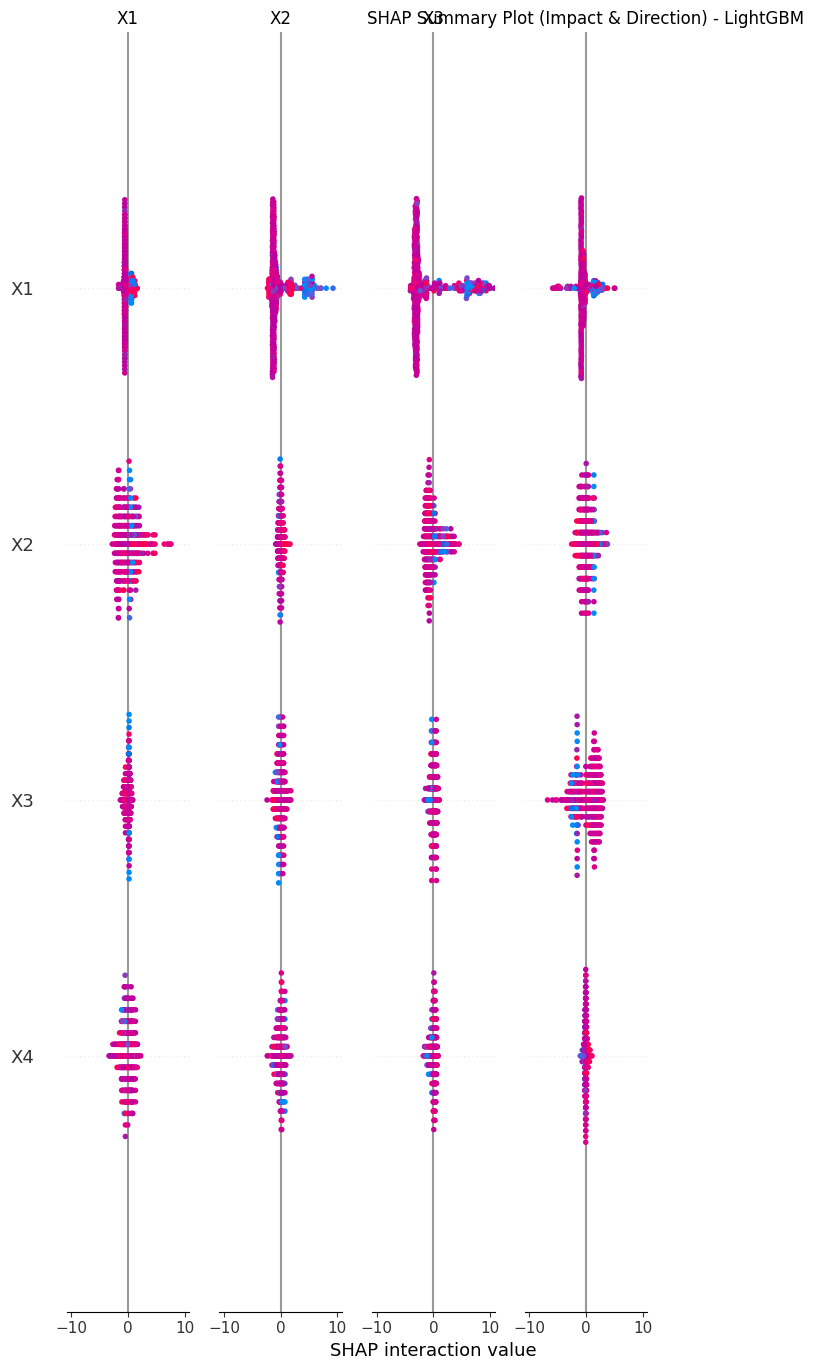

In [18]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Best Model
best_model = models['LightGBM']

print("Computing SHAP values for LightGBM (Multi-class)...")

explainer = shap.TreeExplainer(best_model)

# Use a sample to speed up (increase if you want more accurate results)
X_test_sample = X_test.iloc[:400]   # Adjust based on your RAM/speed

shap_values = explainer.shap_values(X_test_sample)

# ====================== GLOBAL SHAP SUMMARY ======================
print("Generating SHAP Summary Plots...")

# 1. Bar Plot - Overall Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", max_display=16, show=False)
plt.title("SHAP Global Feature Importance (LightGBM - Multi-class)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Beeswarm / Summary Plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_sample, max_display=16, show=False)
plt.title("SHAP Summary Plot (Impact & Direction) - LightGBM")
plt.tight_layout()
plt.show()
